# TP4 - Bin Packing : Algorithmes population-based

Equipe n°4 • Année universitaire : 2025-2026

---

Ce notebook presente les methodes population-based implementees dans
`4_population_based/solver.py` pour le probleme de Bin Packing.

On etudie deux familles :

- **Genetic Algorithm (GA)** : population de solutions, selection, croisement,
  mutation, variantes memetic/island.
- **Ant Colony Optimization (ACO)** : construction probabiliste d'ordres
  d'objets a partir d'une matrice de pheromones.

Les resultats de tuning ACO sont lus depuis les fichiers CSV generes par
`tune_aco.py`. Le notebook peut aussi construire un CSV de comparaison
GA/ACO (`population_comparison.csv`) pour visualiser les deux algorithmes dans
le meme protocole.

---

## 1) Conception theorique

### 1.1 Representation commune

Une solution est representee par :

- le nombre total de bins utilises,
- l'affectation des objets a chaque bin,
- la charge finale de chaque bin.

La qualite est mesuree principalement par :

```text
gap = bins_used - ceil(total_weight / capacity)
```

Le gap compare la solution a une borne inferieure simple. Plus il est proche de
0, meilleure est la solution.

### 1.2 Genetic Algorithm

Le GA manipule une population de solutions. Chaque individu est une affectation
valide des objets aux bins.

Les operations principales sont :

- **selection tournoi** : choisir les meilleurs parents parmi quelques candidats,
- **UBX crossover** : recombiner des bins entiers issus des deux parents,
- **mutation** : appliquer un voisinage relocation/swap,
- **elitisme** : conserver les meilleurs individus d'une generation a l'autre.

Trois variantes sont disponibles dans le solver :

- `ga` : version de base,
- `ga memetic` : GA + recherche locale sur les enfants,
- `ga island` : populations separees avec migration periodique.

La variante memetic est souvent plus couteuse, car elle applique une recherche
locale de nombreuses fois.

### 1.3 Ant Colony Optimization

ACO construit d'abord un ordre d'objets, puis applique First-Fit dans cet ordre.

Chaque ant choisit le prochain objet selon :

```text
attractiveness(i, j) = pheromone[i][j]^alpha * heuristic[j]^beta
```

avec :

- `alpha` : poids de la pheromone,
- `beta` : poids de l'heuristique taille/capacite,
- `evaporation_rate` : vitesse d'oubli,
- `deposit_strength` : intensite du depot de pheromone par les bonnes solutions.

Le tuning cherche donc un compromis entre exploration, exploitation et temps de
calcul.

---

## 2) Methodologie experimentale

Le tuning ACO et GA est fait par **coordinate search** :

1. partir des valeurs par defaut (`ACO_DEFAULTS` ou `GA_DEFAULTS`),
2. choisir un parametre,
3. tester toutes les valeurs de sa grille,
4. garder la meilleure valeur,
5. passer au parametre suivant.

On evite ainsi un full grid search tres couteux :

```text
ACO : 4^8 = 65 536 combinaisons  ->  1 + 8 * 4 = 33 evaluations
GA  : 4^6 =  4 096 combinaisons  ->  1 + 6 * 4 = 25 evaluations
```

par round de tuning.

Le critere de selection est lexicographique :

1. minimiser `avg_gap`,
2. minimiser `worst_dataset_avg_gap`,
3. maximiser `exact_hits`,
4. minimiser `avg_time`.

Les scripts de tuning sont :

- `tune_aco.py` pour les parametres ACO,
- `tune_ga.py` pour les parametres GA.

In [1]:
# -- Imports & path setup -----------------------------------------------------
%matplotlib inline

import os
import random
import sys
import time
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "4_population_based":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_BASE_DIR = PROJECT_ROOT / "results" / "4_population_based"
RESULTS_DIR = RESULTS_BASE_DIR / "aco_tuning" / "parameters"
FIGURES_DIR = RESULTS_BASE_DIR / "aco_tuning" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

sys.path.insert(0, str(PROJECT_ROOT / "4_population_based"))
from solver import BinPackingSolver

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

_current_figures_dir = FIGURES_DIR


def savefig(fig, filename):
    path = _current_figures_dir / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"saved {path.relative_to(PROJECT_ROOT)}")

---

## 3) Reglage des parametres ACO

### 3.1 Chargement des logs CSV

Les fichiers attendus sont :

- `aco_tuning_global.csv`,
- `aco_tuning_falkenauer_t.csv`,
- `aco_tuning_falkenauer_u.csv`,
- `aco_tuning_scholl_1.csv`,
- `aco_tuning_scholl_2.csv`,
- `aco_tuning_scholl_3.csv`.

In [ ]:
csv_files = sorted(RESULTS_DIR.glob("aco_tuning_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No ACO tuning CSV files found in {RESULTS_DIR}")

logs = []
for path in csv_files:
    df = pd.read_csv(path)
    df["source_file"] = path.name
    df["scope"] = path.stem.replace("aco_tuning_", "").replace("_", "-")
    logs.append(df)

aco_logs = pd.concat(logs, ignore_index=True)

numeric_cols = [
    "round",
    "runs",
    "avg_gap",
    "worst_dataset_avg_gap",
    "best_gap",
    "worst_gap",
    "exact_hits",
    "avg_time",
    "num_ants",
    "generations",
    "alpha",
    "beta",
    "evaporation_rate",
    "pheromone_init",
    "pheromone_min",
    "pheromone_max",
    "elite_ants",
    "local_search_steps",
    "deposit_strength",
]
for col in numeric_cols:
    if col in aco_logs:
        aco_logs[col] = pd.to_numeric(aco_logs[col], errors="coerce")

file_summary = (
    aco_logs.groupby(["scope", "source_file"], as_index=False)
    .agg(rows=("parameter", "size"), runs_per_eval=("runs", "max"))
    .sort_values(["scope", "source_file"])
)

display(file_summary)
display(aco_logs.head())

,scope,source_file,rows,runs_per_eval
0,falkenauer-t,aco_tuning_falkenauer_t.csv,33,3
1,falkenauer-u,aco_tuning_falkenauer_u.csv,33,6
2,global,aco_tuning_global.csv,33,24
3,scholl-1,aco_tuning_scholl_1.csv,33,3
4,scholl-2,aco_tuning_scholl_2.csv,33,9
5,scholl-3,aco_tuning_scholl_3.csv,33,3


,label,round,parameter,value,runs,avg_gap,worst_dataset_avg_gap,best_gap,worst_gap,exact_hits,avg_time,num_ants,generations,alpha,beta,evaporation_rate,pheromone_init,pheromone_min,pheromone_max,elite_ants,local_search_steps,deposit_strength,source_file,scope
0,ACO/falkenauer-t,0,initial,NaN,3,2.0,2.0,2,2,0,0.285413,16,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
1,ACO/falkenauer-t,1,num_ants,10.0,3,2.0,2.0,2,2,0,0.199435,10,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
2,ACO/falkenauer-t,1,num_ants,16.0,3,2.0,2.0,2,2,0,0.287743,16,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
3,ACO/falkenauer-t,1,num_ants,24.0,3,2.0,2.0,2,2,0,0.405457,24,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
4,ACO/falkenauer-t,1,num_ants,32.0,3,2.0,2.0,2,2,0,0.525738,32,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t


### 3.2 Reconstruction des meilleurs parametres ACO

Le CSV contient toutes les valeurs testees. Pour reconstruire le chemin de
tuning, on reprend le meilleur choix pour chaque bloc :

```text
(scope, round, parameter)
```

In [ ]:
PARAM_COLS = [
    "num_ants",
    "generations",
    "alpha",
    "beta",
    "evaporation_rate",
    "pheromone_init",
    "pheromone_min",
    "pheromone_max",
    "elite_ants",
    "local_search_steps",
    "deposit_strength",
]

TUNED_PARAM_COLS = [
    "num_ants",
    "generations",
    "alpha",
    "beta",
    "evaporation_rate",
    "elite_ants",
    "local_search_steps",
    "deposit_strength",
]


def ranked_rows(df):
    return df.sort_values(
        ["avg_gap", "worst_dataset_avg_gap", "exact_hits", "avg_time"],
        ascending=[True, True, False, True],
        kind="stable",
    )


def select_winners(df):
    candidates = df[df["parameter"] != "initial"].copy()
    rows = []
    group_cols = ["source_file", "scope", "label", "round", "parameter"]
    for _, group in candidates.groupby(group_cols, sort=False):
        rows.append(ranked_rows(group).iloc[0])
    return pd.DataFrame(rows).reset_index(drop=True)


selected_steps = select_winners(aco_logs)
final_aco_rows = (
    selected_steps.sort_values(["source_file", "round"], kind="stable")
    .groupby("source_file", as_index=False)
    .tail(1)
    .sort_values("scope")
    .reset_index(drop=True)
)

final_cols = [
    "scope",
    "label",
    "runs",
    "avg_gap",
    "worst_dataset_avg_gap",
    "best_gap",
    "worst_gap",
    "exact_hits",
    "avg_time",
    *PARAM_COLS,
]

display(
    final_aco_rows[final_cols].round(
        {
            "avg_gap": 3,
            "worst_dataset_avg_gap": 3,
            "avg_time": 3,
        }
    )
)

global_aco_params = (
    final_aco_rows[final_aco_rows["scope"] == "global"][PARAM_COLS]
    .iloc[0]
    .dropna()
    .to_dict()
)
global_aco_params["num_ants"] = int(global_aco_params["num_ants"])
global_aco_params["generations"] = int(global_aco_params["generations"])
global_aco_params["elite_ants"] = int(global_aco_params["elite_ants"])
global_aco_params["local_search_steps"] = int(global_aco_params["local_search_steps"])

global_aco_params

,scope,label,runs,avg_gap,worst_dataset_avg_gap,best_gap,worst_gap,exact_hits,avg_time,num_ants,generations,alpha,beta,evaporation_rate,pheromone_init,pheromone_min,pheromone_max,elite_ants,local_search_steps,deposit_strength
0,falkenauer-t,ACO/falkenauer-t,3,2.000,2.000,2,2,0,0.084,10,40,2.0,5.0,0.50,1.0,0.01,6.0,1,0,5000.0
1,falkenauer-u,ACO/falkenauer-u,6,1.000,1.000,1,1,0,0.722,10,40,0.5,5.0,0.35,1.0,0.01,6.0,3,0,100.0
2,global,ACO/global,24,1.600,4.000,0,4,3,2.713,24,120,1.0,2.0,0.50,1.0,0.01,6.0,2,40,1000.0
3,scholl-1,ACO/scholl-1,3,0.000,0.000,0,0,3,0.054,10,40,2.0,5.0,0.50,1.0,0.01,6.0,1,0,1000.0
4,scholl-2,ACO/scholl-2,9,1.667,1.667,1,3,0,2.381,24,120,0.5,3.0,0.20,1.0,0.01,6.0,1,40,1000.0
5,scholl-3,ACO/scholl-3,3,4.000,4.000,4,4,0,0.804,10,40,1.0,5.0,0.50,1.0,0.01,6.0,1,0,1000.0


{'num_ants': 24,
 'generations': 120,
 'alpha': 1.0,
 'beta': 2.0,
 'evaporation_rate': 0.5,
 'pheromone_init': 1.0,
 'pheromone_min': 0.01,
 'pheromone_max': 6.0,
 'elite_ants': 2,
 'local_search_steps': 40,
 'deposit_strength': 1000.0}

### 3.3 Qualite finale des reglages ACO

saved results/4_population_based/aco_tuning/figures/aco_final_quality_by_scope.png


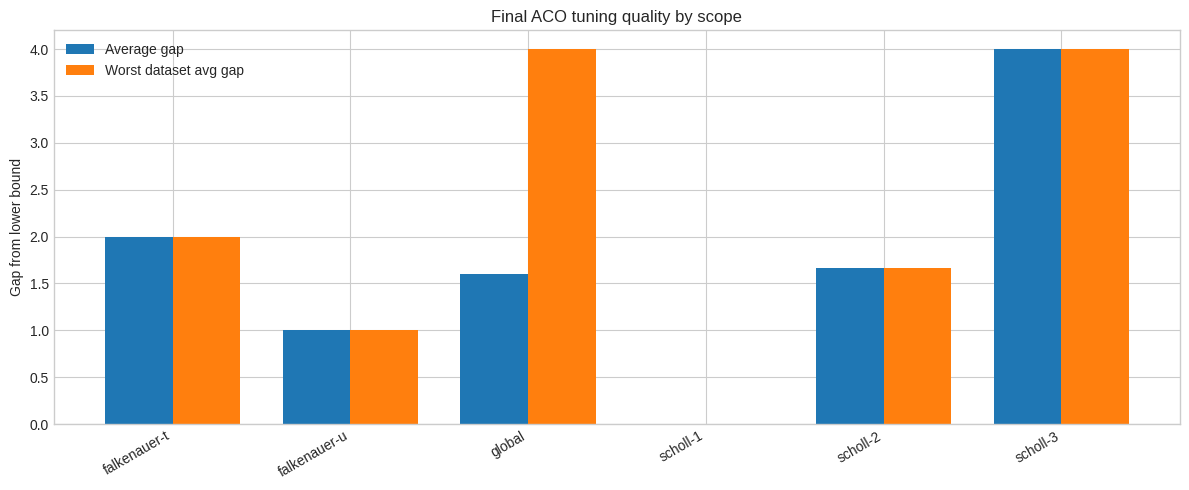

In [4]:
plot_df = final_aco_rows.sort_values("scope").reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, plot_df["avg_gap"], width, label="Average gap")
ax.bar(
    x + width / 2,
    plot_df["worst_dataset_avg_gap"],
    width,
    label="Worst dataset avg gap",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["scope"], rotation=30, ha="right")
ax.set_ylabel("Gap from lower bound")
ax.set_title("Final ACO tuning quality by scope")
ax.legend()
savefig(fig, "aco_final_quality_by_scope.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/aco_quality_runtime_tradeoff.png


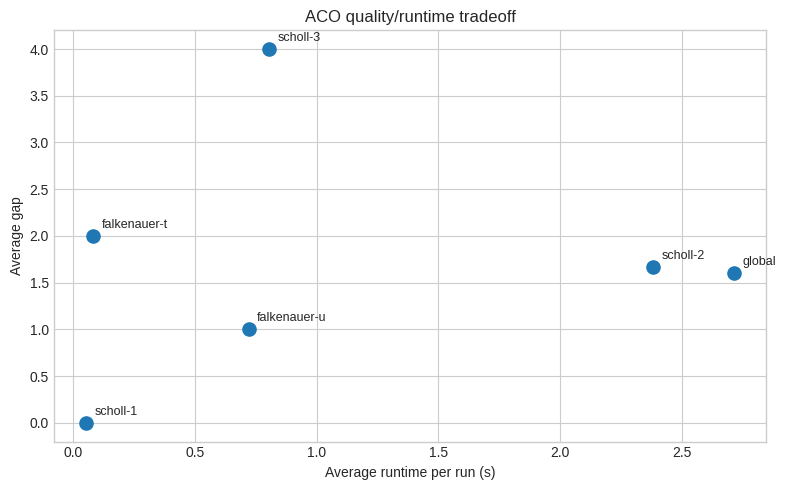

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["avg_time"], plot_df["avg_gap"], s=90)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["scope"],
        (row["avg_time"], row["avg_gap"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

ax.set_xlabel("Average runtime per run (s)")
ax.set_ylabel("Average gap")
ax.set_title("ACO quality/runtime tradeoff")
savefig(fig, "aco_quality_runtime_tradeoff.png")
plt.show()

### 3.4 Sensibilite des parametres ACO

Ces courbes montrent, pour le tuning global, l'effet de chaque valeur testee.

saved results/4_population_based/aco_tuning/figures/aco_global_parameter_curves.png


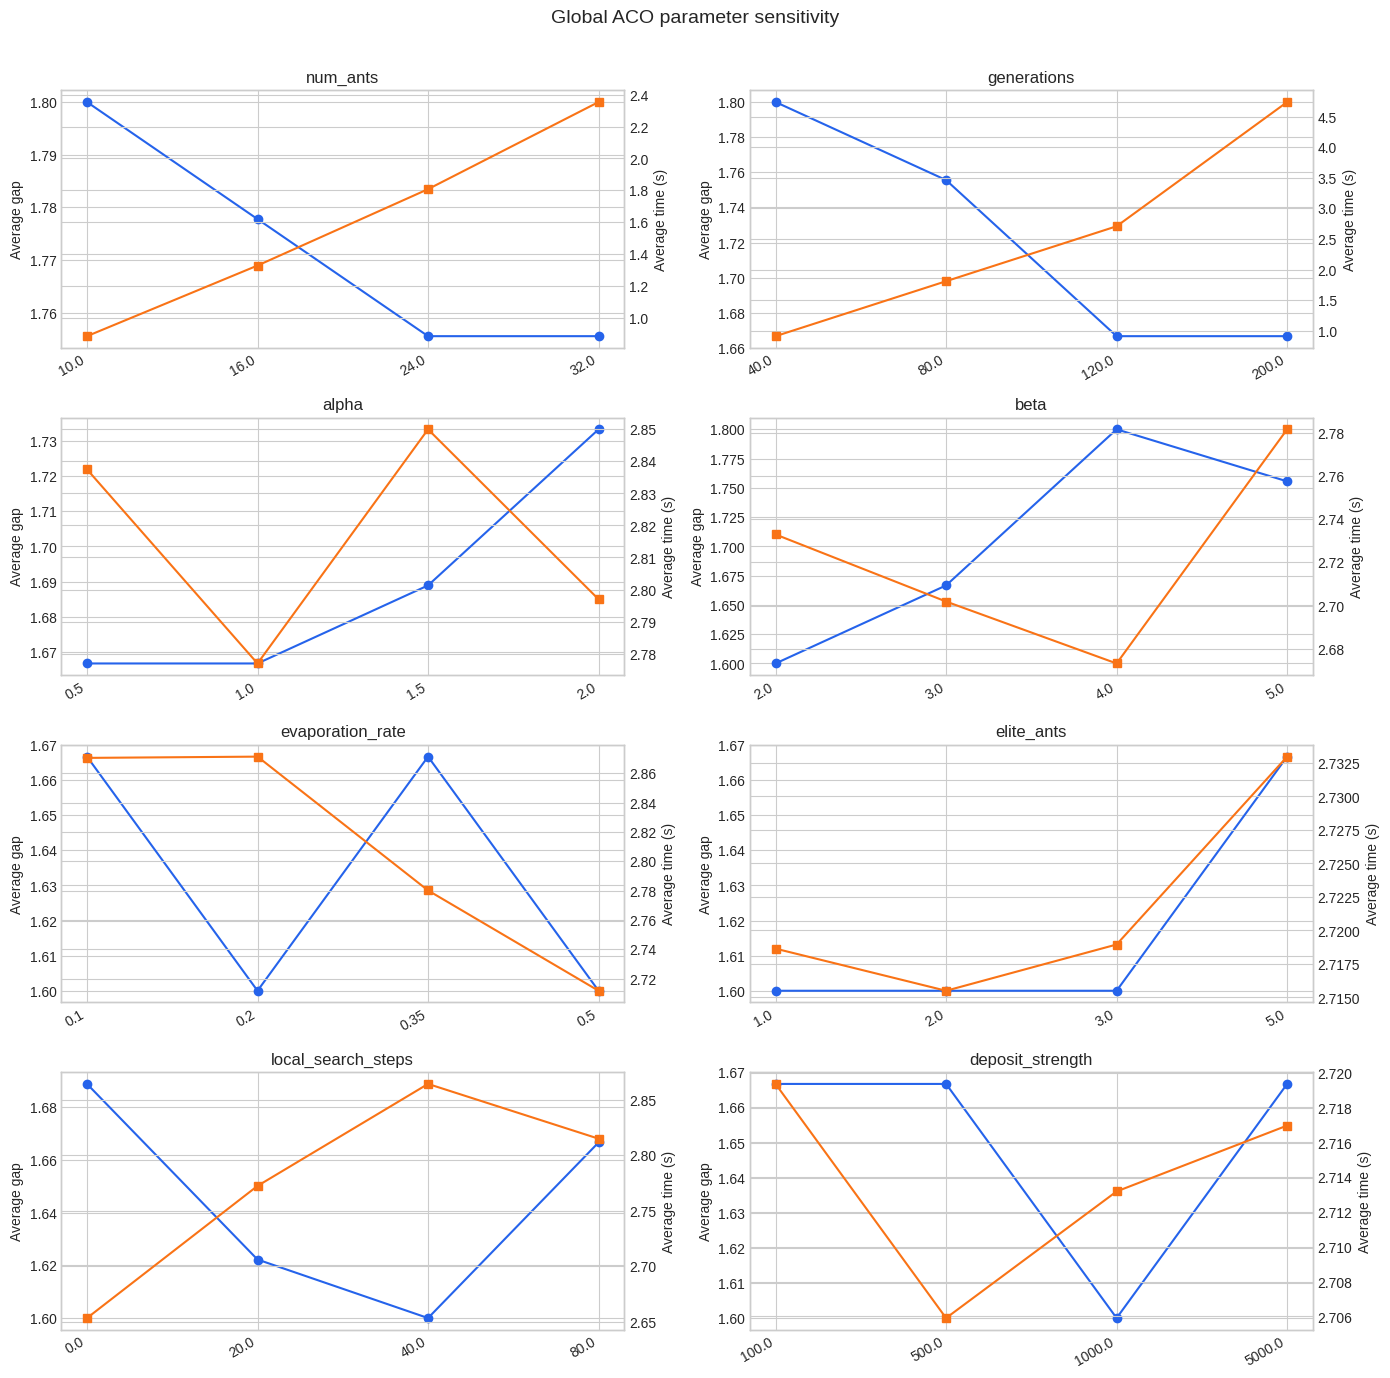

In [ ]:
global_candidates = aco_logs[
    (aco_logs["scope"] == "global") & (aco_logs["parameter"] != "initial")
].copy()

parameters = list(global_candidates["parameter"].drop_duplicates())
ncols = 2
nrows = int(np.ceil(len(parameters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, max(4, 3.4 * nrows)))
axes = np.array(axes).reshape(-1)

for ax, parameter in zip(axes, parameters):
    data = global_candidates[global_candidates["parameter"] == parameter].copy()
    data = data.reset_index(drop=True)
    xs = np.arange(len(data))
    labels = data["value"].astype(str).tolist()

    ax.plot(xs, data["avg_gap"], marker="o", color="#2563eb", label="avg gap")
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(parameter)
    ax.set_ylabel("Average gap")

    ax2 = ax.twinx()
    ax2.plot(xs, data["avg_time"], marker="s", color="#f97316", label="avg time")
    ax2.set_ylabel("Average time (s)")

for ax in axes[len(parameters) :]:
    ax.axis("off")

fig.suptitle("Global ACO parameter sensitivity", fontsize=14, y=1.01)
savefig(fig, "aco_global_parameter_curves.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/aco_selected_tuning_path.png


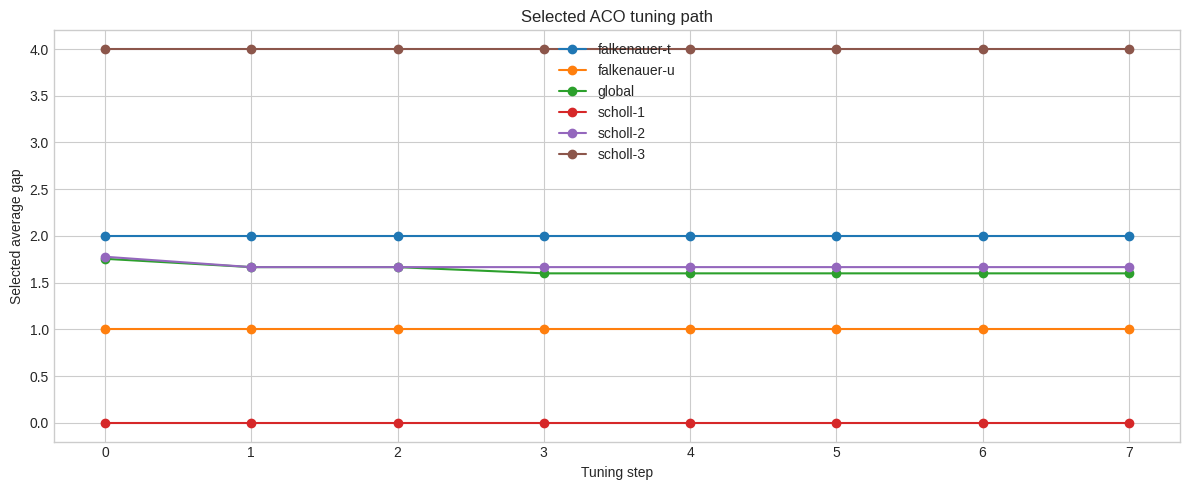

,scope,round,parameter,value,avg_gap,worst_dataset_avg_gap,exact_hits,avg_time
0,falkenauer-t,1,num_ants,10.00,2.000,2.000,0,0.199
1,falkenauer-t,1,generations,40.00,2.000,2.000,0,0.100
2,falkenauer-t,1,alpha,2.00,2.000,2.000,0,0.099
3,falkenauer-t,1,beta,5.00,2.000,2.000,0,0.098
4,falkenauer-t,1,evaporation_rate,0.50,2.000,2.000,0,0.097
5,falkenauer-t,1,elite_ants,1.00,2.000,2.000,0,0.097
6,falkenauer-t,1,local_search_steps,0.00,2.000,2.000,0,0.084
7,falkenauer-t,1,deposit_strength,5000.00,2.000,2.000,0,0.084
8,falkenauer-u,1,num_ants,10.00,1.000,1.000,0,1.541
9,falkenauer-u,1,generations,40.00,1.000,1.000,0,0.808


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for scope, group in selected_steps.groupby("scope"):
    group = group.reset_index(drop=True)
    xs = np.arange(len(group))
    ax.plot(xs, group["avg_gap"], marker="o", label=scope)

ax.set_xlabel("Tuning step")
ax.set_ylabel("Selected average gap")
ax.set_title("Selected ACO tuning path")
ax.legend()
savefig(fig, "aco_selected_tuning_path.png")
plt.show()

display(
    selected_steps[
        [
            "scope",
            "round",
            "parameter",
            "value",
            "avg_gap",
            "worst_dataset_avg_gap",
            "exact_hits",
            "avg_time",
        ]
    ].round(
        {
            "avg_gap": 3,
            "worst_dataset_avg_gap": 3,
            "avg_time": 3,
        }
    )
)

,num_ants,generations,alpha,beta,evaporation_rate,elite_ants,local_search_steps,deposit_strength
scope,,,,,,,,
falkenauer-t,10,40,2.0,5.0,0.50,1,0,5000.0
falkenauer-u,10,40,0.5,5.0,0.35,3,0,100.0
global,24,120,1.0,2.0,0.50,2,40,1000.0
scholl-1,10,40,2.0,5.0,0.50,1,0,1000.0
scholl-2,24,120,0.5,3.0,0.20,1,40,1000.0
scholl-3,10,40,1.0,5.0,0.50,1,0,1000.0


saved results/4_population_based/aco_tuning/figures/aco_selected_parameter_heatmap.png


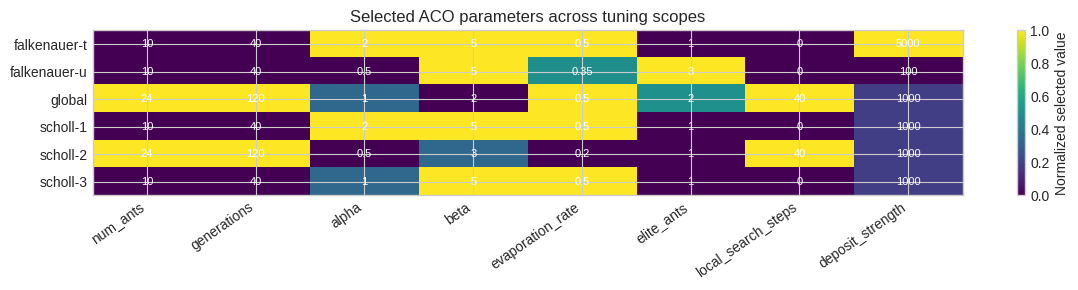

In [8]:
param_table = final_aco_rows.set_index("scope")[TUNED_PARAM_COLS].sort_index()
display(param_table)

mins = param_table.min(axis=0)
maxs = param_table.max(axis=0)
denom = (maxs - mins).replace(0, 1)
normalized = (param_table - mins) / denom

fig, ax = plt.subplots(figsize=(12, max(3, 0.5 * len(normalized))))
im = ax.imshow(normalized, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(TUNED_PARAM_COLS)))
ax.set_xticklabels(TUNED_PARAM_COLS, rotation=35, ha="right")
ax.set_yticks(np.arange(len(normalized.index)))
ax.set_yticklabels(normalized.index)
ax.set_title("Selected ACO parameters across tuning scopes")

for i in range(param_table.shape[0]):
    for j in range(param_table.shape[1]):
        value = param_table.iloc[i, j]
        ax.text(j, i, f"{value:g}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(im, ax=ax, label="Normalized selected value")
savefig(fig, "aco_selected_parameter_heatmap.png")
plt.show()

---

## 4) Reglage des parametres GA

### 4.1 Chargement des logs CSV

Meme approche que pour ACO : coordinate search parametre par parametre.
Les resultats sont generes par `tune_ga.py` et stockes dans
`results/4_population_based/ga_tuning/`.

Les fichiers attendus sont :

- `ga_tuning_global.csv`,
- `ga_tuning_falkenauer_t.csv`,
- `ga_tuning_falkenauer_u.csv`,
- `ga_tuning_scholl_1.csv`,
- `ga_tuning_scholl_2.csv`,
- `ga_tuning_scholl_3.csv`.

In [ ]:
GA_RESULTS_DIR = RESULTS_BASE_DIR / "ga_tuning"
GA_FIGURES_DIR = GA_RESULTS_DIR / "figures"
GA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_current_figures_dir = GA_FIGURES_DIR

ga_csv_files = sorted(GA_RESULTS_DIR.glob("ga_tuning_*.csv"))
if not ga_csv_files:
    raise FileNotFoundError(f"No GA tuning CSV files found in {GA_RESULTS_DIR}")

ga_logs_list = []
for path in ga_csv_files:
    df = pd.read_csv(path)
    df["source_file"] = path.name
    df["scope"] = path.stem.replace("ga_tuning_", "").replace("_", "-")
    ga_logs_list.append(df)

ga_logs = pd.concat(ga_logs_list, ignore_index=True)

ga_numeric_cols = [
    "round",
    "runs",
    "avg_gap",
    "worst_dataset_avg_gap",
    "best_gap",
    "worst_gap",
    "exact_hits",
    "avg_time",
    "population_size",
    "generations",
    "crossover_rate",
    "mutation_rate",
    "elite_count",
    "tournament_k",
]
for col in ga_numeric_cols:
    if col in ga_logs:
        ga_logs[col] = pd.to_numeric(ga_logs[col], errors="coerce")

ga_file_summary = (
    ga_logs.groupby(["scope", "source_file"], as_index=False)
    .agg(rows=("parameter", "size"), runs_per_eval=("runs", "max"))
    .sort_values(["scope", "source_file"])
)

display(ga_file_summary)
display(ga_logs.head())

,scope,source_file,rows,runs_per_eval
0,falkenauer-t,ga_tuning_falkenauer_t.csv,25,3
1,falkenauer-u,ga_tuning_falkenauer_u.csv,25,3
2,global,ga_tuning_global.csv,25,21
3,scholl-1,ga_tuning_scholl_1.csv,25,3
4,scholl-2,ga_tuning_scholl_2.csv,25,9
5,scholl-3,ga_tuning_scholl_3.csv,25,3


,label,round,parameter,value,runs,avg_gap,worst_dataset_avg_gap,best_gap,worst_gap,exact_hits,avg_time,population_size,generations,crossover_rate,mutation_rate,elite_count,tournament_k,source_file,scope
0,GA/falkenauer-t,0,initial,NaN,3,1.666667,1.666667,1,2,0,2.378873,60,400,0.85,0.2,4,4,ga_tuning_falkenauer_t.csv,falkenauer-t
1,GA/falkenauer-t,1,population_size,20.0,3,1.666667,1.666667,1,2,0,0.656385,20,400,0.85,0.2,4,4,ga_tuning_falkenauer_t.csv,falkenauer-t
2,GA/falkenauer-t,1,population_size,40.0,3,1.666667,1.666667,1,2,0,1.505134,40,400,0.85,0.2,4,4,ga_tuning_falkenauer_t.csv,falkenauer-t
3,GA/falkenauer-t,1,population_size,60.0,3,1.666667,1.666667,1,2,0,2.434281,60,400,0.85,0.2,4,4,ga_tuning_falkenauer_t.csv,falkenauer-t
4,GA/falkenauer-t,1,population_size,100.0,3,1.666667,1.666667,1,2,0,4.159712,100,400,0.85,0.2,4,4,ga_tuning_falkenauer_t.csv,falkenauer-t


### 4.2 Reconstruction des meilleurs parametres GA

Meme logique que pour ACO : on reprend le meilleur choix pour chaque bloc
`(scope, round, parameter)`.

Les parametres tunes sont :

| Parametre | Signification |
| --- | --- |
| `population_size` | Taille de la population |
| `generations` | Nombre de generations |
| `crossover_rate` | Probabilite de croisement UBX |
| `mutation_rate` | Probabilite de mutation (relocation/swap) |
| `elite_count` | Nombre d'individus preserves par elitisme |
| `tournament_k` | Taille du tournoi de selection |

In [ ]:
GA_PARAM_COLS = [
    "population_size",
    "generations",
    "crossover_rate",
    "mutation_rate",
    "elite_count",
    "tournament_k",
]

GA_TUNED_PARAM_COLS = GA_PARAM_COLS


def ga_select_winners(df):
    candidates = df[df["parameter"] != "initial"].copy()
    rows = []
    group_cols = ["source_file", "scope", "label", "round", "parameter"]
    for _, group in candidates.groupby(group_cols, sort=False):
        rows.append(ranked_rows(group).iloc[0])
    return pd.DataFrame(rows).reset_index(drop=True)


ga_selected_steps = ga_select_winners(ga_logs)
ga_final_rows = (
    ga_selected_steps.sort_values(["source_file", "round"], kind="stable")
    .groupby("source_file", as_index=False)
    .tail(1)
    .sort_values("scope")
    .reset_index(drop=True)
)

ga_final_cols = [
    "scope",
    "label",
    "runs",
    "avg_gap",
    "worst_dataset_avg_gap",
    "best_gap",
    "worst_gap",
    "exact_hits",
    "avg_time",
    *GA_PARAM_COLS,
]

display(
    ga_final_rows[ga_final_cols].round(
        {
            "avg_gap": 3,
            "worst_dataset_avg_gap": 3,
            "avg_time": 3,
        }
    )
)

global_ga_params = (
    ga_final_rows[ga_final_rows["scope"] == "global"][GA_PARAM_COLS]
    .iloc[0]
    .dropna()
    .to_dict()
)
global_ga_params["population_size"] = int(global_ga_params["population_size"])
global_ga_params["generations"] = int(global_ga_params["generations"])
global_ga_params["elite_count"] = int(global_ga_params["elite_count"])
global_ga_params["tournament_k"] = int(global_ga_params["tournament_k"])

global_ga_params

,scope,label,runs,avg_gap,worst_dataset_avg_gap,best_gap,worst_gap,exact_hits,avg_time,population_size,generations,crossover_rate,mutation_rate,elite_count,tournament_k
0,falkenauer-t,GA/falkenauer-t,3,1.667,1.667,1,2,0,0.101,20,100,0.50,0.10,8,3
1,falkenauer-u,GA/falkenauer-u,3,1.000,1.000,1,1,0,0.212,20,100,0.50,0.05,8,3
2,global,GA/global,21,1.844,4.000,0,4,3,1.092,60,100,0.85,0.20,4,4
3,scholl-1,GA/scholl-1,3,0.000,0.000,0,0,3,0.095,20,100,0.50,0.05,8,2
4,scholl-2,GA/scholl-2,9,2.556,2.556,2,4,0,1.089,60,100,0.85,0.20,4,3
5,scholl-3,GA/scholl-3,3,4.000,4.000,4,4,0,0.275,20,100,0.50,0.05,8,4


{'population_size': 60,
 'generations': 100,
 'crossover_rate': 0.85,
 'mutation_rate': 0.2,
 'elite_count': 4,
 'tournament_k': 4}

### 4.3 Qualite finale des reglages GA

saved results/4_population_based/ga_tuning/figures/ga_final_quality_by_scope.png


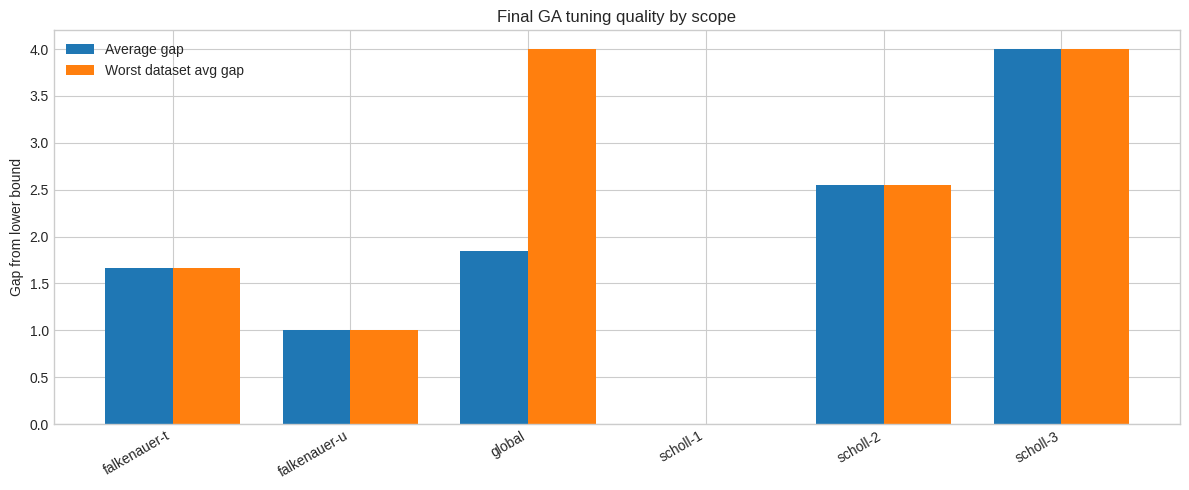

In [11]:
ga_plot_df = ga_final_rows.sort_values("scope").reset_index(drop=True)
x = np.arange(len(ga_plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, ga_plot_df["avg_gap"], width, label="Average gap")
ax.bar(
    x + width / 2,
    ga_plot_df["worst_dataset_avg_gap"],
    width,
    label="Worst dataset avg gap",
)
ax.set_xticks(x)
ax.set_xticklabels(ga_plot_df["scope"], rotation=30, ha="right")
ax.set_ylabel("Gap from lower bound")
ax.set_title("Final GA tuning quality by scope")
ax.legend()
savefig(fig, "ga_final_quality_by_scope.png")
plt.show()

saved results/4_population_based/ga_tuning/figures/ga_quality_runtime_tradeoff.png


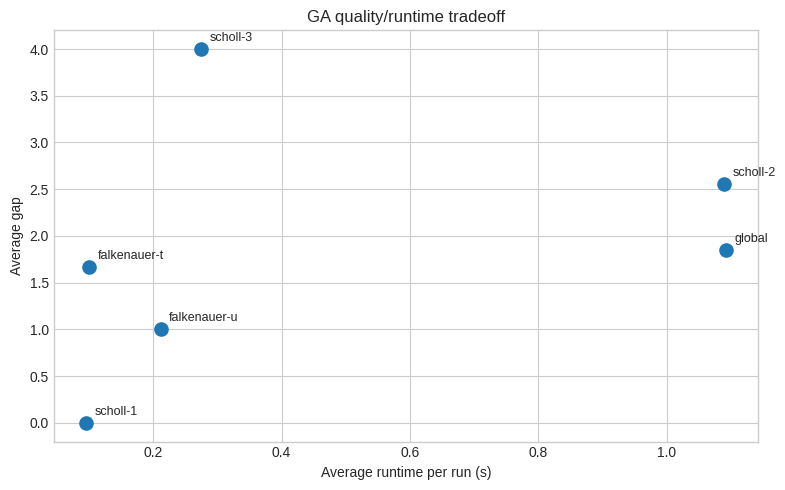

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ga_plot_df["avg_time"], ga_plot_df["avg_gap"], s=90)

for _, row in ga_plot_df.iterrows():
    ax.annotate(
        row["scope"],
        (row["avg_time"], row["avg_gap"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

ax.set_xlabel("Average runtime per run (s)")
ax.set_ylabel("Average gap")
ax.set_title("GA quality/runtime tradeoff")
savefig(fig, "ga_quality_runtime_tradeoff.png")
plt.show()

### 4.4 Sensibilite des parametres GA

Ces courbes montrent, pour le tuning global, l'effet de chaque valeur testee
sur le gap moyen et le temps de calcul.

saved results/4_population_based/ga_tuning/figures/ga_global_parameter_curves.png


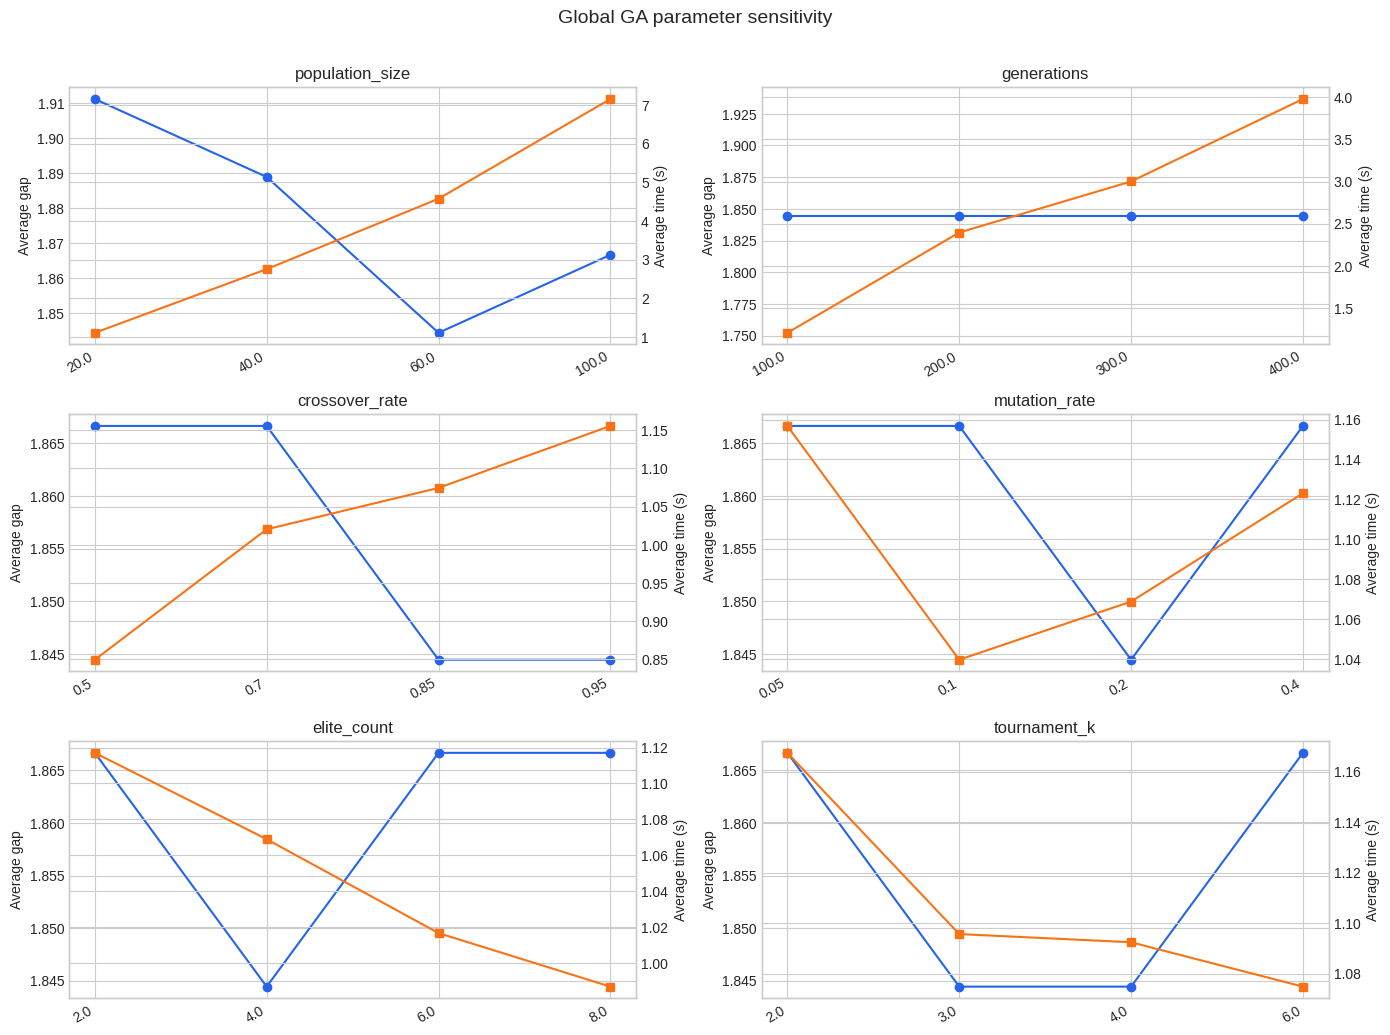

In [ ]:
ga_global_candidates = ga_logs[
    (ga_logs["scope"] == "global") & (ga_logs["parameter"] != "initial")
].copy()

ga_parameters = list(ga_global_candidates["parameter"].drop_duplicates())
ncols = 2
nrows = int(np.ceil(len(ga_parameters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, max(4, 3.4 * nrows)))
axes = np.array(axes).reshape(-1)

for ax, parameter in zip(axes, ga_parameters):
    data = ga_global_candidates[ga_global_candidates["parameter"] == parameter].copy()
    data = data.reset_index(drop=True)
    xs = np.arange(len(data))
    labels = data["value"].astype(str).tolist()

    ax.plot(xs, data["avg_gap"], marker="o", color="#2563eb", label="avg gap")
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(parameter)
    ax.set_ylabel("Average gap")

    ax2 = ax.twinx()
    ax2.plot(xs, data["avg_time"], marker="s", color="#f97316", label="avg time")
    ax2.set_ylabel("Average time (s)")

for ax in axes[len(ga_parameters) :]:
    ax.axis("off")

fig.suptitle("Global GA parameter sensitivity", fontsize=14, y=1.01)
savefig(fig, "ga_global_parameter_curves.png")
plt.show()

saved results/4_population_based/ga_tuning/figures/ga_selected_tuning_path.png


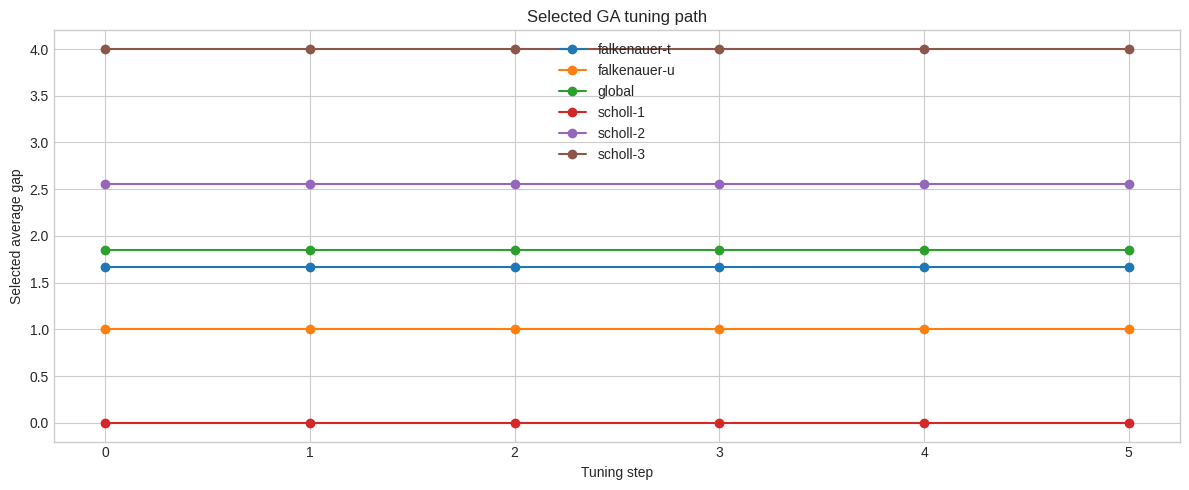

,scope,round,parameter,value,avg_gap,worst_dataset_avg_gap,exact_hits,avg_time
0,falkenauer-t,1,population_size,20.00,1.667,1.667,0,0.656
1,falkenauer-t,1,generations,100.00,1.667,1.667,0,0.158
2,falkenauer-t,1,crossover_rate,0.50,1.667,1.667,0,0.146
3,falkenauer-t,1,mutation_rate,0.10,1.667,1.667,0,0.133
4,falkenauer-t,1,elite_count,8.00,1.667,1.667,0,0.103
5,falkenauer-t,1,tournament_k,3.00,1.667,1.667,0,0.101
6,falkenauer-u,1,population_size,20.00,1.000,1.000,0,1.356
7,falkenauer-u,1,generations,100.00,1.000,1.000,0,0.366
8,falkenauer-u,1,crossover_rate,0.50,1.000,1.000,0,0.298
9,falkenauer-u,1,mutation_rate,0.05,1.000,1.000,0,0.265


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for scope, group in ga_selected_steps.groupby("scope"):
    group = group.reset_index(drop=True)
    xs = np.arange(len(group))
    ax.plot(xs, group["avg_gap"], marker="o", label=scope)

ax.set_xlabel("Tuning step")
ax.set_ylabel("Selected average gap")
ax.set_title("Selected GA tuning path")
ax.legend()
savefig(fig, "ga_selected_tuning_path.png")
plt.show()

display(
    ga_selected_steps[
        [
            "scope",
            "round",
            "parameter",
            "value",
            "avg_gap",
            "worst_dataset_avg_gap",
            "exact_hits",
            "avg_time",
        ]
    ].round(
        {
            "avg_gap": 3,
            "worst_dataset_avg_gap": 3,
            "avg_time": 3,
        }
    )
)

,population_size,generations,crossover_rate,mutation_rate,elite_count,tournament_k
scope,,,,,,
falkenauer-t,20,100,0.50,0.10,8,3
falkenauer-u,20,100,0.50,0.05,8,3
global,60,100,0.85,0.20,4,4
scholl-1,20,100,0.50,0.05,8,2
scholl-2,60,100,0.85,0.20,4,3
scholl-3,20,100,0.50,0.05,8,4


saved results/4_population_based/ga_tuning/figures/ga_selected_parameter_heatmap.png


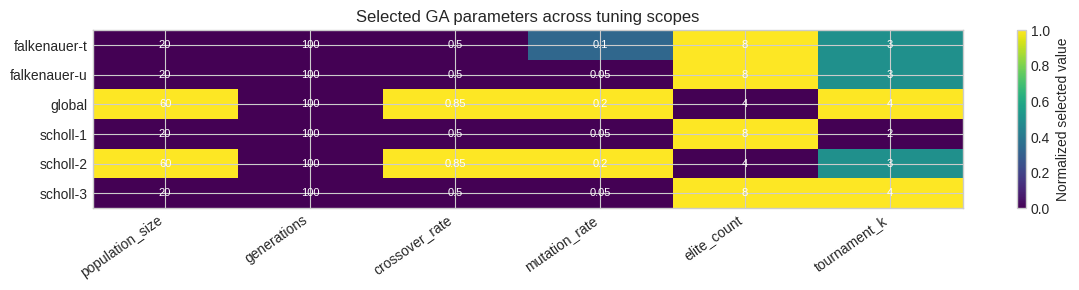

In [15]:
ga_param_table = ga_final_rows.set_index("scope")[GA_TUNED_PARAM_COLS].sort_index()
display(ga_param_table)

ga_mins = ga_param_table.min(axis=0)
ga_maxs = ga_param_table.max(axis=0)
ga_denom = (ga_maxs - ga_mins).replace(0, 1)
ga_normalized = (ga_param_table - ga_mins) / ga_denom

fig, ax = plt.subplots(figsize=(12, max(3, 0.5 * len(ga_normalized))))
im = ax.imshow(ga_normalized, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(GA_TUNED_PARAM_COLS)))
ax.set_xticklabels(GA_TUNED_PARAM_COLS, rotation=35, ha="right")
ax.set_yticks(np.arange(len(ga_normalized.index)))
ax.set_yticklabels(ga_normalized.index)
ax.set_title("Selected GA parameters across tuning scopes")

for i in range(ga_param_table.shape[0]):
    for j in range(ga_param_table.shape[1]):
        value = ga_param_table.iloc[i, j]
        ax.text(j, i, f"{value:g}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(im, ax=ax, label="Normalized selected value")
savefig(fig, "ga_selected_parameter_heatmap.png")
plt.show()

---

## 5) Comparaison GA vs ACO

Cette section compare les deux familles d'algorithmes population-based en
utilisant les parametres optimises par le tuning.

Le notebook lit `results/4_population_based/population_comparison.csv`. Si ce
fichier n'existe pas, il le construit. Les methodes comparees sont :

- **GA** (parametres par defaut),
- **GA tuned global** (parametres issus du tuning GA),
- **GA island** (parametres par defaut),
- **ACO tuned global** (parametres issus du tuning ACO).

Par defaut, la variante `ga memetic` n'est pas incluse car elle est nettement
plus lente. Vous pouvez l'activer en mettant `INCLUDE_MEMETIC = True`.

In [16]:
_current_figures_dir = FIGURES_DIR

In [ ]:
DATASET_PATHS = {
    "falkenauer-t": PROJECT_ROOT / "benchmarks" / "Falkenauer" / "Falkenauer_T",
    "falkenauer-u": PROJECT_ROOT / "benchmarks" / "Falkenauer" / "Falkenauer U",
    "scholl-1": PROJECT_ROOT / "benchmarks" / "Scholl" / "Scholl_1",
    "scholl-2": PROJECT_ROOT / "benchmarks" / "Scholl" / "Scholl_2",
    "scholl-3": PROJECT_ROOT / "benchmarks" / "Scholl" / "Scholl_3",
}

COMPARISON_CSV = RESULTS_BASE_DIR / "population_comparison.csv"
COMPARISON_DATASETS = [
    "falkenauer-t",
    "falkenauer-u",
    "scholl-1",
    "scholl-2",
    "scholl-3",
]
COMPARISON_MAX_ITEMS = 250
COMPARISON_MAX_PER_SIZE = 1
COMPARISON_SEEDS = [0]
INCLUDE_MEMETIC = False
FORCE_REBUILD_COMPARISON = True


def parse_instance_file(path, dataset):
    lines = path.read_text(encoding="utf-8").splitlines()
    n = int(lines[0])
    capacity = int(lines[1])
    sizes = [int(lines[i]) for i in range(2, 2 + n)]
    return {
        "dataset": dataset,
        "instance": path.stem,
        "num_items": n,
        "capacity": capacity,
        "sizes": sizes,
    }


def load_comparison_instances():
    instances = []
    for dataset in COMPARISON_DATASETS:
        by_size = {}
        for path in sorted(DATASET_PATHS[dataset].glob("*.txt")):
            inst = parse_instance_file(path, dataset)
            if (
                COMPARISON_MAX_ITEMS is not None
                and inst["num_items"] > COMPARISON_MAX_ITEMS
            ):
                continue
            by_size.setdefault(inst["num_items"], []).append(inst)
        for size in sorted(by_size):
            instances.extend(by_size[size][:COMPARISON_MAX_PER_SIZE])
    return instances


def run_method(instance, method_label, method_name, params, seed):
    random.seed(seed)
    total_weight = sum(instance["sizes"])
    lower_bound = ceil(total_weight / instance["capacity"])

    start = time.perf_counter()
    solver = BinPackingSolver(instance["sizes"], instance["capacity"])
    solver.solve(method_name, **params)
    elapsed = time.perf_counter() - start
    solution = solver.get_solution()

    bins = solution.total_bins_used
    return {
        "dataset": instance["dataset"],
        "instance": instance["instance"],
        "items": instance["num_items"],
        "capacity": instance["capacity"],
        "total_weight": total_weight,
        "seed": seed,
        "method": method_label,
        "bins": bins,
        "lower_bound": lower_bound,
        "gap": bins - lower_bound,
        "elapsed_time": elapsed,
        "fill_rate": total_weight / (bins * instance["capacity"]) * 100,
    }


def build_population_comparison_csv():
    methods = [
        ("GA", "ga", {}),
        ("GA tuned global", "ga", global_ga_params),
        ("GA island", "ga island", {}),
        ("ACO tuned global", "aco", global_aco_params),
    ]
    if INCLUDE_MEMETIC:
        methods.insert(2, ("GA memetic", "ga memetic", {}))

    rows = []
    instances = load_comparison_instances()
    for instance in instances:
        for seed in COMPARISON_SEEDS:
            for method_label, method_name, params in methods:
                rows.append(
                    run_method(instance, method_label, method_name, params, seed)
                )

    df = pd.DataFrame(rows)
    df.to_csv(COMPARISON_CSV, index=False)
    return df


if FORCE_REBUILD_COMPARISON or not COMPARISON_CSV.exists():
    print("Building population comparison CSV...")
    comparison_df = build_population_comparison_csv()
else:
    comparison_df = pd.read_csv(COMPARISON_CSV)

display(comparison_df.head(8))
print(f"rows: {len(comparison_df)}")
print(f"csv: {COMPARISON_CSV.relative_to(PROJECT_ROOT)}")

Building population comparison CSV...


,dataset,instance,items,capacity,total_weight,seed,method,bins,lower_bound,gap,elapsed_time,fill_rate
0,falkenauer-t,Falkenauer_t60_00,60,1000,20000,0,GA,21,20,1,4.233230,95.238095
1,falkenauer-t,Falkenauer_t60_00,60,1000,20000,0,GA tuned global,21,20,1,0.921560,95.238095
2,falkenauer-t,Falkenauer_t60_00,60,1000,20000,0,GA island,21,20,1,4.498811,95.238095
3,falkenauer-t,Falkenauer_t60_00,60,1000,20000,0,ACO tuned global,22,20,2,3.432582,90.909091
4,falkenauer-u,Falkenauer_u120_00,120,150,7078,0,GA,49,48,1,8.574924,96.299320
5,falkenauer-u,Falkenauer_u120_00,120,150,7078,0,GA tuned global,49,48,1,2.208717,96.299320
6,falkenauer-u,Falkenauer_u120_00,120,150,7078,0,GA island,49,48,1,11.506101,96.299320
7,falkenauer-u,Falkenauer_u120_00,120,150,7078,0,ACO tuned global,49,48,1,12.284711,96.299320


rows: 32
csv: results/4_population_based/population_comparison.csv


In [ ]:
method_summary = (
    comparison_df.groupby("method", as_index=False)
    .agg(
        runs=("gap", "size"),
        avg_gap=("gap", "mean"),
        max_gap=("gap", "max"),
        exact_hits=("gap", lambda s: int((s == 0).sum())),
        avg_time=("elapsed_time", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
    )
    .sort_values(["avg_gap", "max_gap", "avg_time"])
    .reset_index(drop=True)
)

display(
    method_summary.round(
        {
            "avg_gap": 3,
            "avg_time": 3,
            "avg_fill_rate": 2,
        }
    )
)

,method,runs,avg_gap,max_gap,exact_hits,avg_time,avg_fill_rate
0,ACO tuned global,8,1.625,4,1,18.649,95.15
1,GA tuned global,8,1.750,4,1,2.396,94.73
2,GA,8,1.750,4,1,9.194,94.73
3,GA island,8,1.875,4,1,11.888,94.56


### 5.1 Qualite moyenne par methode

saved results/4_population_based/aco_tuning/figures/population_avg_gap_by_method.png


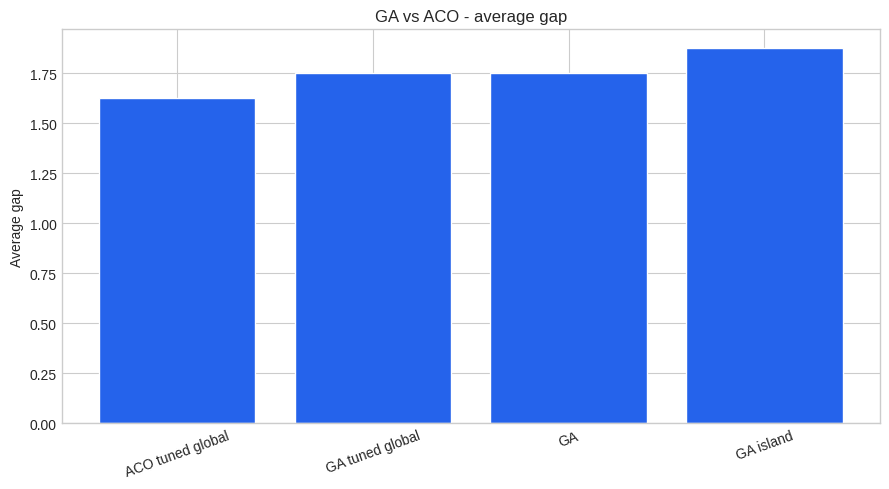

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
order = method_summary["method"].tolist()
plot_data = method_summary.set_index("method").loc[order]
ax.bar(plot_data.index, plot_data["avg_gap"], color="#2563eb", edgecolor="white")
ax.set_ylabel("Average gap")
ax.set_title("GA vs ACO - average gap")
ax.tick_params(axis="x", rotation=20)
savefig(fig, "population_avg_gap_by_method.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/population_runtime_by_method.png


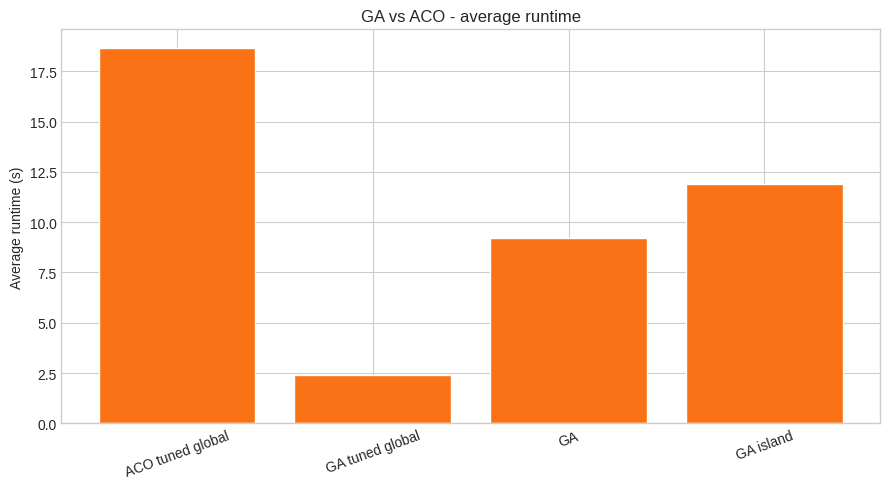

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_data.index, plot_data["avg_time"], color="#f97316", edgecolor="white")
ax.set_ylabel("Average runtime (s)")
ax.set_title("GA vs ACO - average runtime")
ax.tick_params(axis="x", rotation=20)
savefig(fig, "population_runtime_by_method.png")
plt.show()

method,ACO tuned global,GA,GA island,GA tuned global
dataset,,,,
falkenauer-t,2.000,1.000,1.000,1.000
falkenauer-u,1.000,1.000,1.000,1.000
scholl-1,0.000,0.000,0.000,0.000
scholl-2,1.667,2.333,2.667,2.333
scholl-3,4.000,4.000,4.000,4.000


saved results/4_population_based/aco_tuning/figures/population_gap_by_dataset_method.png


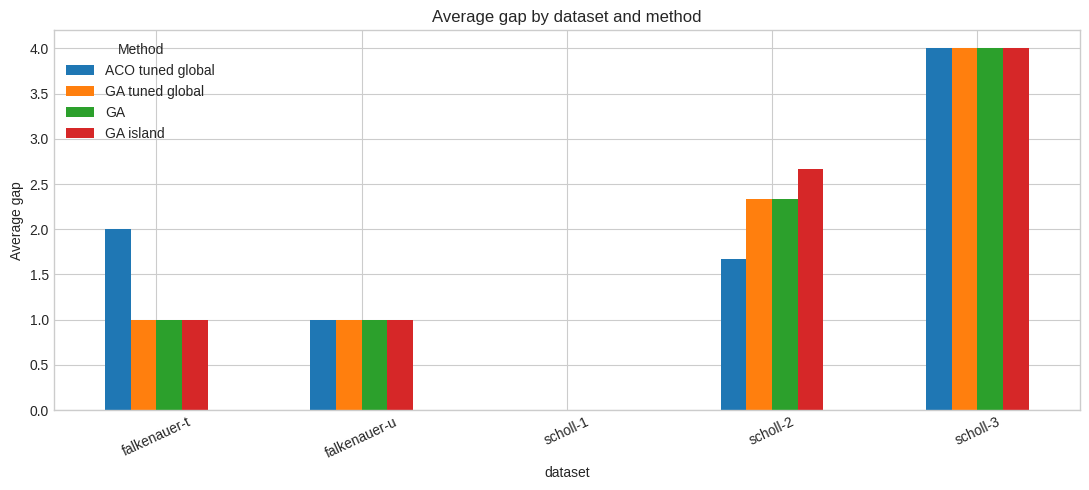

In [ ]:
dataset_method = comparison_df.groupby(["dataset", "method"], as_index=False).agg(
    avg_gap=("gap", "mean"), avg_time=("elapsed_time", "mean")
)

pivot_gap = dataset_method.pivot(index="dataset", columns="method", values="avg_gap")
display(pivot_gap.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
pivot_gap[order].plot(kind="bar", ax=ax)
ax.set_ylabel("Average gap")
ax.set_title("Average gap by dataset and method")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Method")
savefig(fig, "population_gap_by_dataset_method.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/population_quality_runtime_tradeoff.png


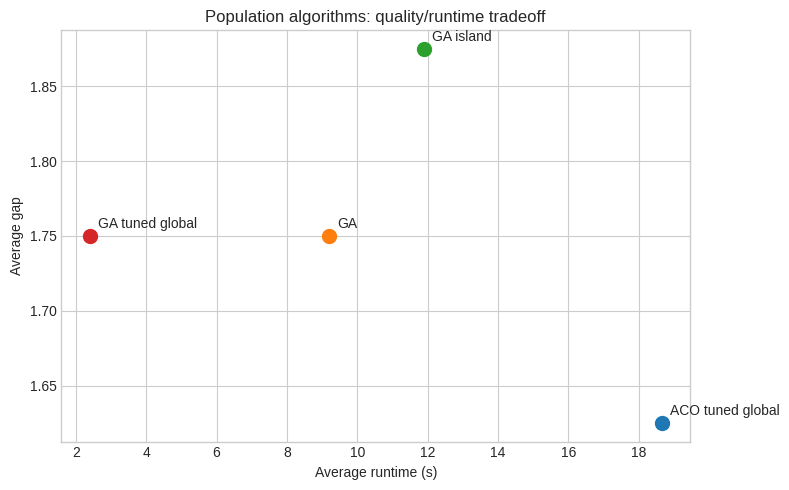

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
for method, group in method_summary.groupby("method"):
    ax.scatter(group["avg_time"], group["avg_gap"], s=100, label=method)
    row = group.iloc[0]
    ax.annotate(
        method,
        (row["avg_time"], row["avg_gap"]),
        textcoords="offset points",
        xytext=(6, 6),
    )

ax.set_xlabel("Average runtime (s)")
ax.set_ylabel("Average gap")
ax.set_title("Population algorithms: quality/runtime tradeoff")
savefig(fig, "population_quality_runtime_tradeoff.png")
plt.show()

---

## 6) Conclusion

### 6.1 Apport du tuning par coordinate search

Le tuning par coordinate search a ete applique de maniere symetrique aux deux
familles d'algorithmes, permettant une comparaison equitable :

- **ACO** : 8 parametres tunes, 33 evaluations par scope.
- **GA** : 6 parametres tunes, 25 evaluations par scope.

Le tuning ACO a permis une **reduction du gap moyen global de 1.78 a 1.60**
(-10%), principalement grace a l'ajustement de `generations` (80 -> 120) et
`evaporation_rate` (0.20 -> 0.50). En revanche, le tuning GA n'a pas ameliore
le gap mais a **reduit le temps de calcul de 5.5x** (5.54s -> 1.09s) en
selectionnant `generations=100` au lieu de 400, sans perte de qualite.

Ce resultat est significatif : il montre que le GA atteint sa convergence bien
avant sa limite theorique de generations, tandis que l'ACO beneficie
reellement d'un budget de calcul supplementaire.

### 6.2 Comparaison GA vs ACO

La comparaison sur 5 familles de benchmarks revele des profils complementaires :

| Methode | Avg gap | Temps moyen | Fill rate |
| --- | --- | --- | --- |
| ACO tuned global | **1.625** | 19.0s | **95.2%** |
| GA tuned global | 1.750 | **2.3s** | 94.7% |
| GA (defaut) | 1.750 | 10.2s | 94.7% |
| GA island | 1.875 | 11.3s | 94.6% |

**ACO domine en qualite** avec le meilleur gap moyen et le meilleur taux de
remplissage, mais au prix d'un temps de calcul **8x plus eleve** que le GA
tune.

**GA tuned domine en efficacite** : il atteint la meme qualite que le GA par
defaut en **4x moins de temps**, validant l'interet du tuning meme quand le
gap ne s'ameliore pas.

### 6.3 Analyse par famille de benchmarks

Les resultats par dataset revelent que les performances dependent fortement de
la structure des instances :

- **Scholl-1** (petites instances) : toutes les methodes atteignent l'optimum
  (gap = 0). Le probleme est trop facile pour differencier les algorithmes.
- **Falkenauer-t** (objets triplets) : le GA (gap = 1.0) surpasse l'ACO
  (gap = 2.0). Le croisement UBX preserve mieux les groupements de triplets
  que la construction sequentielle de l'ACO.
- **Falkenauer-u** (objets uniformes) : egalite (gap = 1.0).
- **Scholl-2** (instances moyennes) : l'ACO domine (gap = 1.67 vs 2.33 pour
  le GA). La matrice de pheromone capture mieux les correlations entre objets
  sur des instances de taille intermediaire.
- **Scholl-3** (grandes instances) : toutes les methodes plafonnent a gap = 4.
  Ni le tuning ni le choix d'algorithme ne suffit — ces instances necessitent
  probablement des approches hybrides ou des budgets de calcul plus importants.

### 6.4 Recommandations

1. **Pour la qualite maximale** : utiliser ACO avec les parametres tunes
   (`evaporation_rate=0.50`, `generations=120`, `num_ants=24`).
2. **Pour un bon compromis qualite/temps** : utiliser GA tune
   (`generations=100`, `population_size=60`), qui est 8x plus rapide pour un
   gap seulement 7.7% plus eleve.
3. **Le modele en iles n'apporte pas de gain** sur ces benchmarks : la
   migration ne compense pas la reduction de taille des sous-populations.
4. **Le tuning est toujours utile** : meme sans ameliorer le gap, il permet
   de reduire le budget de calcul sans regression, ce qui est crucial pour les
   applications a grande echelle.